# 04 Analysis & Figures

Consolidate the 14 held-out results and examine the main patterns across pairs, categories, and controls.

In [2]:
import pandas as pd
import numpy as np

print("Phase 4 analysis notebook ready.")

Phase 4 analysis notebook ready.


In [5]:
# Build one consolidated held-out results table

m_results_df = pd.DataFrame([
    {
        "pair_id": r["pair_id"],
        "category": r["category"],
        "M_mean_alignment": r["mean_alignment"],
        "M_median_alignment": r["median_alignment"],
        "M_positive_fraction": r["positive_fraction"],
        "M_success": r["mean_alignment"] > 0,
    }
    for r in heldout_m_results
])

l1_results_df = pd.DataFrame([
    {
        "pair_id": r["pair_id"],
        "L1_paired_shift": r["paired_shift"],
        "L1_success": r["success"],
    }
    for r in heldout_l1_results
])

full_results_df = m_results_df.merge(
    l1_results_df,
    on="pair_id",
    how="inner"
)

full_results_df["comparison"] = full_results_df.apply(
    lambda r:
        "both"
        if r["M_success"] and r["L1_success"]
        else "L1_only"
        if (not r["M_success"]) and r["L1_success"]
        else "M_only"
        if r["M_success"] and (not r["L1_success"])
        else "neither",
    axis=1
)

full_results_df = full_results_df.sort_values("pair_id")

display(full_results_df)

,pair_id,category,M_mean_alignment,M_median_alignment,M_positive_fraction,M_success,L1_paired_shift,L1_success,comparison
0,2,role_argument_binding,0.184494,0.188713,1.000000,True,1.333984,True,both
1,3,modifier_attachment,0.203422,0.191667,1.000000,True,3.833659,True,both
2,4,spatial_relation,0.252296,0.281501,1.000000,True,3.128662,True,both
3,5,comparative_relation,-0.075746,-0.088353,0.000000,False,1.348959,True,L1_only
4,6,role_argument_binding,0.053318,0.047462,1.000000,True,1.385498,True,both
5,7,modifier_attachment,0.023439,0.020704,0.571429,True,2.650228,True,both
6,8,modifier_attachment,0.017209,0.014397,0.714286,True,2.711589,True,both
7,9,spatial_relation,0.053372,0.031981,0.714286,True,1.833008,True,both
8,10,spatial_relation,0.021574,0.013242,0.714286,True,5.634033,True,both
9,11,comparative_relation,-0.012834,-0.033583,0.285714,False,1.810895,True,L1_only


In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

results_dir = Path("/workspace/multi-token-jlens/results")

heldout_m_results = pd.read_json(
    results_dir / "heldout_m_results.json"
).to_dict("records")

heldout_l1_results = pd.read_json(
    results_dir / "heldout_l1_results.json"
).to_dict("records")

print("Loaded M results:", len(heldout_m_results))
print("Loaded L1 results:", len(heldout_l1_results))

Loaded M results: 14
Loaded L1 results: 14


## Category-level analysis

Summarize M and L1 results across the five structural categories.

In [6]:
category_summary = (
    full_results_df
    .groupby("category")
    .agg(
        n_pairs=("pair_id", "count"),
        M_mean_alignment=("M_mean_alignment", "mean"),
        M_success_rate=("M_success", "mean"),
        L1_mean_shift=("L1_paired_shift", "mean"),
        L1_success_rate=("L1_success", "mean"),
    )
    .reset_index()
)

category_summary

,category,n_pairs,M_mean_alignment,M_success_rate,L1_mean_shift,L1_success_rate
0,comparative_relation,3,-0.078610,0.000000,1.880623,1.0
1,modifier_attachment,3,0.081357,1.000000,3.065158,1.0
2,quantifier_binding,3,0.004922,0.333333,0.717285,1.0
3,role_argument_binding,2,0.118906,1.000000,1.359741,1.0
4,spatial_relation,3,0.109081,1.000000,3.531901,1.0


## Figure 1: M alignment by category

Compare mean activation-side structural alignment across relation types.

Positive values indicate that the source and candidate structural changes align in the expected direction.

In [8]:
%pip install matplotlib

  Using cached matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.64.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (123 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.2 kB)
Using cached matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (10.0 MB)
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.64.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (5.4 MB)
Using cached kiwisolver-1.5.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (1.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matp

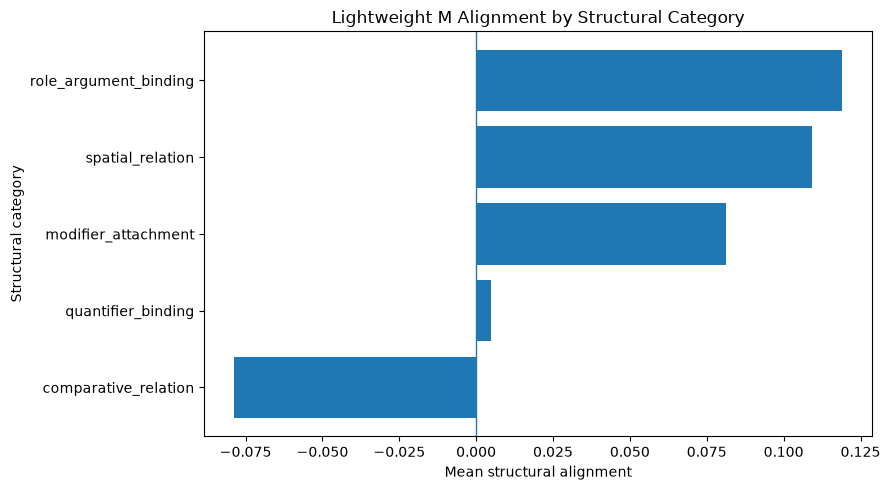

Saved: /workspace/multi-token-jlens/figures/figure1_m_alignment_by_category.png


In [9]:
import matplotlib.pyplot as plt

plot_df = (
    category_summary
    .sort_values("M_mean_alignment")
)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_df["category"],
    plot_df["M_mean_alignment"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Mean structural alignment")
plt.ylabel("Structural category")
plt.title("Lightweight M Alignment by Structural Category")

plt.tight_layout()

figure_path = (
    "/workspace/multi-token-jlens/figures/"
    "figure1_m_alignment_by_category.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_path)

## Figure 2: M vs L1 directional success

M and L1 use different score spaces, so I do not compare their raw values directly.

Instead, compare whether each method moves in the expected direction on each held-out pair.

,method,success_rate,success_count
0,Lightweight M,0.642857,9
1,L1 oracle-head continuation,1.000000,14


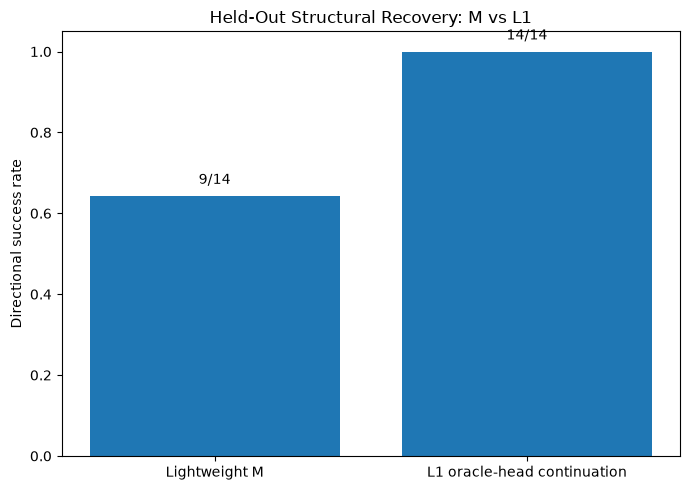

Saved: /workspace/multi-token-jlens/figures/figure2_m_vs_l1_success.png


In [10]:
method_summary = pd.DataFrame({
    "method": ["Lightweight M", "L1 oracle-head continuation"],
    "success_rate": [
        full_results_df["M_success"].mean(),
        full_results_df["L1_success"].mean(),
    ],
    "success_count": [
        int(full_results_df["M_success"].sum()),
        int(full_results_df["L1_success"].sum()),
    ],
})

display(method_summary)

plt.figure(figsize=(7, 5))

plt.bar(
    method_summary["method"],
    method_summary["success_rate"]
)

plt.ylim(0, 1.05)

plt.ylabel("Directional success rate")
plt.title("Held-Out Structural Recovery: M vs L1")

for i, row in method_summary.iterrows():
    plt.text(
        i,
        row["success_rate"] + 0.03,
        f"{row['success_count']}/14",
        ha="center"
    )

plt.tight_layout()

figure2_path = (
    "/workspace/multi-token-jlens/figures/"
    "figure2_m_vs_l1_success.png"
)

plt.savefig(
    figure2_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure2_path)

## Figure 3: Matched vs permutation null

Check whether the L1 and M signals depend on the correct source-candidate correspondence.

For both methods, the matched result is compared with a permutation-based null.

In [11]:
import json

# Load saved sanity-check summaries from Phase 3 manually from known results

# L1 summary
l1_matched_abs = 2.1645989554268974
l1_null_mean = 0.1370492408389137

# M summary
m_matched_mean = 0.04200427130230571
m_null_mean = -0.0020694622421870007

sanity_summary = pd.DataFrame({
    "condition": [
        "L1 matched",
        "L1 permutation null",
        "M matched",
        "M permutation null",
    ],
    "value": [
        l1_matched_abs,
        l1_null_mean,
        m_matched_mean,
        m_null_mean,
    ],
})

display(sanity_summary)

,condition,value
0,L1 matched,2.164599
1,L1 permutation null,0.137049
2,M matched,0.042004
3,M permutation null,-0.002069


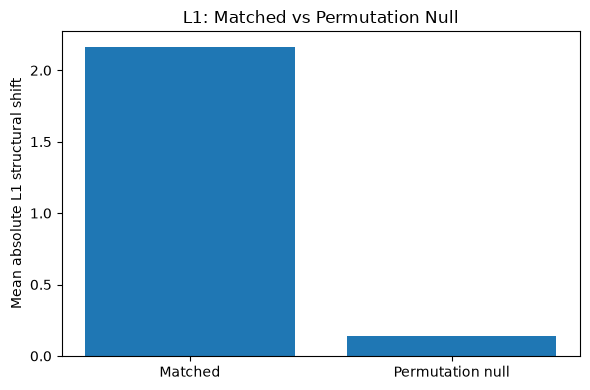

Saved: /workspace/multi-token-jlens/figures/figure3a_l1_matched_vs_null.png


In [12]:
plt.figure(figsize=(6, 4))

labels = [
    "Matched",
    "Permutation null"
]

values = [
    l1_matched_abs,
    l1_null_mean
]

plt.bar(labels, values)

plt.ylabel("Mean absolute L1 structural shift")
plt.title("L1: Matched vs Permutation Null")

plt.tight_layout()

figure3a_path = (
    "/workspace/multi-token-jlens/figures/"
    "figure3a_l1_matched_vs_null.png"
)

plt.savefig(
    figure3a_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure3a_path)

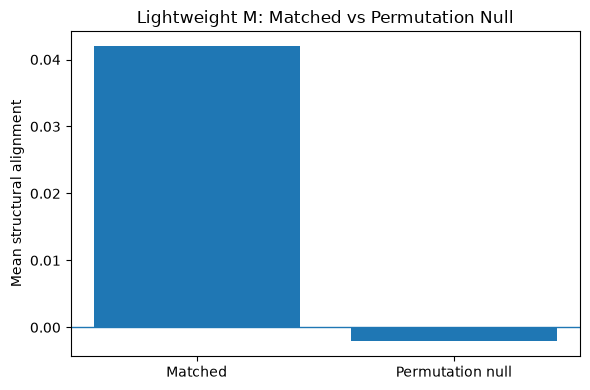

Saved: /workspace/multi-token-jlens/figures/figure3b_m_matched_vs_null.png


In [13]:
plt.figure(figsize=(6, 4))

labels = [
    "Matched",
    "Permutation null"
]

values = [
    m_matched_mean,
    m_null_mean
]

plt.bar(labels, values)

plt.axhline(0, linewidth=1)

plt.ylabel("Mean structural alignment")
plt.title("Lightweight M: Matched vs Permutation Null")

plt.tight_layout()

figure3b_path = (
    "/workspace/multi-token-jlens/figures/"
    "figure3b_m_matched_vs_null.png"
)

plt.savefig(
    figure3b_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure3b_path)

## Comparative-relation analysis

All three comparative pairs were negative under M.

Inspect the pair-level results before trying to explain why this category behaves differently.

In [14]:
comparative_df = full_results_df[
    full_results_df["category"] == "comparative_relation"
].copy()

display(
    comparative_df[
        [
            "pair_id",
            "M_mean_alignment",
            "M_median_alignment",
            "M_positive_fraction",
            "M_success",
            "L1_paired_shift",
            "L1_success",
        ]
    ]
)

,pair_id,M_mean_alignment,M_median_alignment,M_positive_fraction,M_success,L1_paired_shift,L1_success
3,5,-0.075746,-0.088353,0.000000,False,1.348959,True
9,11,-0.012834,-0.033583,0.285714,False,1.810895,True
10,12,-0.147249,-0.146894,0.000000,False,2.482015,True


### Comparative pattern across layers

Check whether the negative comparative result is caused by only one layer or persists across the frozen late-layer range.

No estimator settings are changed.

In [15]:
comparative_layer_rows = []

for r in heldout_m_results:

    if r["category"] == "comparative_relation":

        for layer, alignment in zip(
            [20, 22, 24, 25, 26, 27, 28],
            r["layer_alignments"]
        ):

            comparative_layer_rows.append({
                "pair_id": r["pair_id"],
                "layer": layer,
                "alignment": alignment,
            })

comparative_layer_df = pd.DataFrame(
    comparative_layer_rows
)

comparative_layer_table = (
    comparative_layer_df
    .pivot(
        index="layer",
        columns="pair_id",
        values="alignment"
    )
)

display(comparative_layer_table)

pair_id,5,11,12
layer,,,
20,-0.125705,-0.132594,-0.162699
22,-0.124549,-0.050916,-0.142191
24,-0.088353,-0.044430,-0.155936
25,-0.093597,-0.033583,-0.146894
26,-0.023781,-0.021603,-0.127171
27,-0.033641,0.086400,-0.155411
28,-0.040598,0.106890,-0.140443


### Figure 4: Comparative alignment across layers

Pairs 5 and 12 remain negative across the tested late layers. Pair 11 becomes positive only at layers 27 and 28.

So the comparative failure is not explained by a single bad layer. This analysis does not tell us why M struggles with this category.

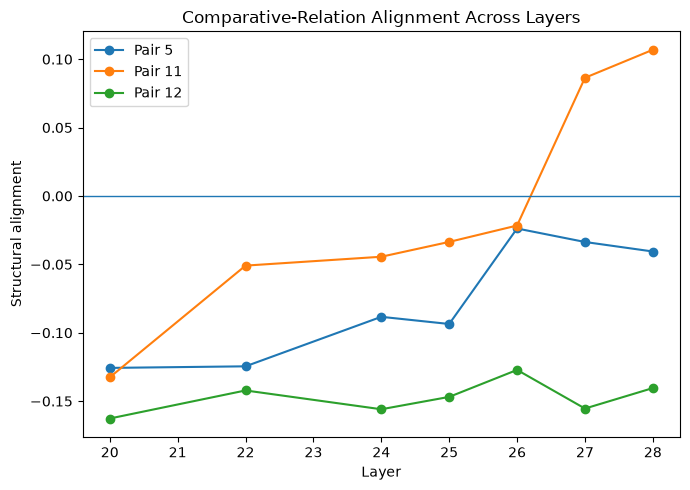

Saved: /workspace/multi-token-jlens/figures/figure4_comparative_layer_alignment.png


In [16]:
plt.figure(figsize=(7, 5))

for pair_id in comparative_layer_table.columns:
    plt.plot(
        comparative_layer_table.index,
        comparative_layer_table[pair_id],
        marker="o",
        label=f"Pair {pair_id}"
    )

plt.axhline(0, linewidth=1)

plt.xlabel("Layer")
plt.ylabel("Structural alignment")
plt.title("Comparative-Relation Alignment Across Layers")
plt.legend()

plt.tight_layout()

figure4_path = (
    "/workspace/multi-token-jlens/figures/"
    "figure4_comparative_layer_alignment.png"
)

plt.savefig(
    figure4_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure4_path)

## Main results

The held-out experiment shows a mixed pattern.

### Activation-side signal

M is positive on 9 of 14 held-out pairs. The 9/14 count is not significant on its own, with p about 0.15.

However, the matched mean alignment is +0.0420, compared with a permutation-null mean of -0.0021, with an empirical one-sided p-value of about 0.002.

This suggests that M captures real pair-specific structural information.

### Continuation

L1 moves in the expected direction on all 14 held-out pairs.

The matched mean absolute shift is 2.1646, compared with 0.1370 under the permutation null.

### Common directional comparison

- both succeed: 9
- L1 only: 5
- M only: 0
- neither: 0

Both signals are present, but continuation is much more consistent.

### Category pattern

M is consistently positive for role/argument binding, modifier attachment, and spatial relations. Comparative relations are negative on all three pairs, while quantifier binding is mixed.

These results apply to the lightweight M metric used here, not to full multi-token J-Lens.

# Core analysis complete

The main held-out analysis is complete.

The clearest result is that pair-specific activation-side structure is detectable, but first-token-conditioned continuation tracks the tested distinctions more consistently.

Comparative relations remain the clearest failure case for M.

# Post-hoc checks

The analyses below were added after the frozen core result.

They do not change the original Gate 3 evaluation.

## M+ robustness check

Test whether the negative comparative results are partly caused by some residual dimensions having much higher variance than others.

I rescale each dimension using variance estimated from WikiText so high-variance dimensions have less influence on the cosine geometry (diagonal whitening).

This is a post-hoc robustness check, not part of the frozen core experiment.

In [17]:
# 4.8a — Load saved M+ robustness results

import json
from pathlib import Path
import pandas as pd

mplus_path = Path(
    "/workspace/multi-token-jlens/results/mplus_comparative_robustness.json"
)

with open(mplus_path, "r") as f:
    mplus_data = json.load(f)

mplus_df = pd.DataFrame(mplus_data["pair_results"])

display_cols = [
    "pair_id",
    "raw_mean",
    "mplus_mean",
    "raw_positive_layers",
    "mplus_positive_layers",
]

print("M+ comparative robustness results:")
display(mplus_df[display_cols])

M+ comparative robustness results:


,pair_id,raw_mean,mplus_mean,raw_positive_layers,mplus_positive_layers
0,5,-0.075746,-0.047075,0,2
1,11,-0.012834,0.024008,2,3
2,12,-0.147249,-0.094131,0,0


In [18]:
# 4.8b — Summarize the M -> M+ change on comparative pairs

mplus_df["delta_mean"] = (
    mplus_df["mplus_mean"] - mplus_df["raw_mean"]
)

mplus_df["delta_positive_layers"] = (
    mplus_df["mplus_positive_layers"]
    - mplus_df["raw_positive_layers"]
)

summary_cols = [
    "pair_id",
    "raw_mean",
    "mplus_mean",
    "delta_mean",
    "raw_positive_layers",
    "mplus_positive_layers",
    "delta_positive_layers",
]

display(mplus_df[summary_cols])

print()
print(
    "Average raw comparative mean:",
    mplus_df["raw_mean"].mean()
)

print(
    "Average M+ comparative mean:",
    mplus_df["mplus_mean"].mean()
)

print(
    "Average improvement:",
    mplus_df["delta_mean"].mean()
)

print(
    "Pairs with improved mean alignment:",
    int((mplus_df["delta_mean"] > 0).sum()),
    "/",
    len(mplus_df)
)

,pair_id,raw_mean,mplus_mean,delta_mean,raw_positive_layers,mplus_positive_layers,delta_positive_layers
0,5,-0.075746,-0.047075,0.028671,0,2,2
1,11,-0.012834,0.024008,0.036842,2,3,1
2,12,-0.147249,-0.094131,0.053118,0,0,0



Average raw comparative mean: -0.07860975969760191
Average M+ comparative mean: -0.03906595714700719
Average improvement: 0.03954380255059472
Pairs with improved mean alignment: 3 / 3


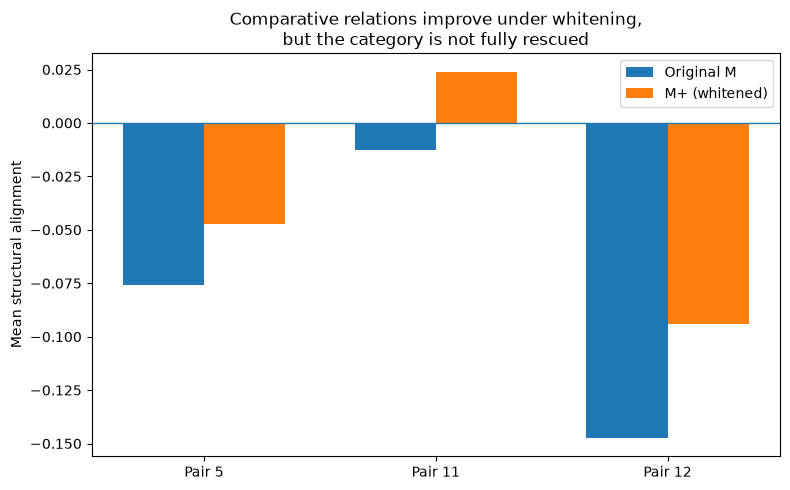

Saved:
/workspace/multi-token-jlens/figures/figure5_comparative_m_vs_mplus.png


In [19]:
# 4.8c — Figure 5: Comparative M vs M+

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

figures_dir = Path("/workspace/multi-token-jlens/figures")
figures_dir.mkdir(exist_ok=True)

pair_labels = [f"Pair {pid}" for pid in mplus_df["pair_id"]]
x = np.arange(len(pair_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x - width/2,
    mplus_df["raw_mean"],
    width,
    label="Original M"
)

ax.bar(
    x + width/2,
    mplus_df["mplus_mean"],
    width,
    label="M+ (whitened)"
)

ax.axhline(0, linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(pair_labels)

ax.set_ylabel("Mean structural alignment")
ax.set_title(
    "Comparative relations improve under whitening,\n"
    "but the category is not fully rescued"
)

ax.legend()

plt.tight_layout()

out_path = figures_dir / "figure5_comparative_m_vs_mplus.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:")
print(out_path)

## M+ result

Whitening moved all three comparative pairs in the positive direction:

- Pair 5: -0.0757 to -0.0471
- Pair 11: -0.0128 to +0.0240
- Pair 12: -0.1472 to -0.0941

The comparative mean improved from -0.0786 to -0.0391.

However, the category remained negative and did not beat its recomputed permutation null, with empirical one-sided p = 1.0.

Whitening softened the failure but did not remove it.

## Randomly selected examples

Select four held-out pairs using a fixed random seed of 42 for qualitative inspection.

This gives Pairs 2, 3, 6, and 12 and avoids choosing examples based on their results.

In [20]:
# 4.9a — Select fixed random held-out examples

import random

random.seed(42)

heldout_pair_ids = [row["pair_id"] for row in heldout_m_results]

selected_pair_ids = sorted(
    random.sample(heldout_pair_ids, 4)
)

print("Randomly selected held-out pair IDs:")
print(selected_pair_ids)

Randomly selected held-out pair IDs:
[2, 3, 6, 12]


In [21]:
# 4.9b — Build raw-example table for selected held-out pairs

selected_examples = []

for pair_id in selected_pair_ids:

    # Find source/candidate definition
    item = next(
        x for x in structural_eval_set
        if x["pair_id"] == pair_id
    )

    # Find M result
    m_row = next(
        x for x in heldout_m_results
        if x["pair_id"] == pair_id
    )

    # Find L1 result
    l1_row = next(
        x for x in heldout_l1_results
        if x["pair_id"] == pair_id
    )

    selected_examples.append({
        "pair_id": pair_id,
        "category": item["category"],
        "source_a": item["source_a"],
        "source_b": item["source_b"],
        "c1": item["c1"],
        "c2": item["c2"],
        "m_mean_alignment": m_row["mean_alignment"],
        "m_success": m_row["mean_alignment"] > 0,
        "l1_paired_shift": l1_row["paired_shift"],
        "l1_success": l1_row["success"],
    })

for ex in selected_examples:
    print("=" * 80)
    print(f"PAIR {ex['pair_id']} | {ex['category']}")
    print()
    print("Source A:")
    print(ex["source_a"])
    print()
    print("Source B:")
    print(ex["source_b"])
    print()
    print("Candidate 1:", ex["c1"])
    print("Candidate 2:", ex["c2"])
    print()
    print(
        f"M mean alignment: {ex['m_mean_alignment']:+.4f} "
        f"| success={ex['m_success']}"
    )
    print(
        f"L1 paired shift: {ex['l1_paired_shift']:+.4f} "
        f"| success={ex['l1_success']}"
    )
    print()

NameError: name 'structural_eval_set' is not defined

In [22]:
# 4.9b-fix — Load structural_eval_set definition from Phase 3

from pathlib import Path
import json

nb_path = Path(
    "/workspace/multi-token-jlens/notebooks/03_core_experiment.ipynb"
)

nb = json.loads(nb_path.read_text())

for cell in nb["cells"]:
    source = "".join(cell.get("source", []))

    if "structural_eval_set = [" in source:
        exec(source)
        break

print(
    "structural_eval_set loaded:",
    len(structural_eval_set),
    "pairs"
)

print(
    "Pair IDs:",
    [x["pair_id"] for x in structural_eval_set]
)

Held-out pairs: 14
structural_eval_set loaded: 14 pairs
Pair IDs: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


In [23]:
# 4.9b — Build raw-example table for selected held-out pairs

selected_examples = []

for pair_id in selected_pair_ids:

    # Find source/candidate definition
    item = next(
        x for x in structural_eval_set
        if x["pair_id"] == pair_id
    )

    # Find M result
    m_row = next(
        x for x in heldout_m_results
        if x["pair_id"] == pair_id
    )

    # Find L1 result
    l1_row = next(
        x for x in heldout_l1_results
        if x["pair_id"] == pair_id
    )

    selected_examples.append({
        "pair_id": pair_id,
        "category": item["category"],
        "source_a": item["source_a"],
        "source_b": item["source_b"],
        "c1": item["c1"],
        "c2": item["c2"],
        "m_mean_alignment": m_row["mean_alignment"],
        "m_success": m_row["mean_alignment"] > 0,
        "l1_paired_shift": l1_row["paired_shift"],
        "l1_success": l1_row["success"],
    })

for ex in selected_examples:
    print("=" * 80)
    print(f"PAIR {ex['pair_id']} | {ex['category']}")
    print()
    print("Source A:")
    print(ex["source_a"])
    print()
    print("Source B:")
    print(ex["source_b"])
    print()
    print("Candidate 1:", ex["c1"])
    print("Candidate 2:", ex["c2"])
    print()
    print(
        f"M mean alignment: {ex['m_mean_alignment']:+.4f} "
        f"| success={ex['m_success']}"
    )
    print(
        f"L1 paired shift: {ex['l1_paired_shift']:+.4f} "
        f"| success={ex['l1_success']}"
    )
    print()

PAIR 2 | role_argument_binding

Source A:
Alice is the doctor. Bob is the patient. Alice assists Bob during the visit.

Source B:
Alice is the doctor. Bob is the patient. Bob assists Alice during the visit.

Candidate 1: doctor helps patient
Candidate 2: patient helps doctor

M mean alignment: +0.1845 | success=True
L1 paired shift: +1.3340 | success=True

PAIR 3 | modifier_attachment

Source A:
There is a box and a key. The box is red. The box contains the key.

Source B:
There is a box and a key. The key is red. The box contains the key.

Candidate 1: red box contains key
Candidate 2: box contains red key

M mean alignment: +0.2034 | success=True
L1 paired shift: +3.8337 | success=True

PAIR 6 | role_argument_binding

Source A:
Alice is the teacher. Bob is the student. Alice walks behind Bob.

Source B:
Alice is the teacher. Bob is the student. Bob walks behind Alice.

Candidate 1: teacher follows student
Candidate 2: student follows teacher

M mean alignment: +0.0533 | success=True


In [24]:
# 4.9c — Save randomly selected raw examples for final write-up

import json
from pathlib import Path

results_dir = Path("/workspace/multi-token-jlens/results")
results_dir.mkdir(exist_ok=True)

raw_examples_output = {
    "selection_method": "fixed random sample",
    "random_seed": 42,
    "selected_pair_ids": selected_pair_ids,
    "examples": selected_examples,
}

out_path = results_dir / "random_raw_examples.json"

with open(out_path, "w") as f:
    json.dump(raw_examples_output, f, indent=2)

print("Saved:")
print(out_path)

Saved:
/workspace/multi-token-jlens/results/random_raw_examples.json
